In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image

sns.set_style("whitegrid")
print("Libraries loaded successfully")

Libraries loaded successfully


In [2]:
DATASET_DIR = "../dataset"
TRAIN_DIR = os.path.join(DATASET_DIR, "train")
TEST_DIR = os.path.join(DATASET_DIR, "test")

CLASSES = sorted(os.listdir(TRAIN_DIR))
print("Classes found:", CLASSES)
print("Total classes:", len(CLASSES))

Classes found: ['angry', 'disgust', 'fear', 'happy', 'neutral', 'sad', 'surprise']
Total classes: 7


In [3]:
def count_images_per_class(directory, classes):
    counts = {}
    for cls in classes:
        cls_path = os.path.join(directory, cls)
        counts[cls] = len(os.listdir(cls_path))
    return counts

train_counts = count_images_per_class(TRAIN_DIR, CLASSES)
test_counts = count_images_per_class(TEST_DIR, CLASSES)

print("Train set counts:")
for cls, count in train_counts.items():
    print(f"  {cls}: {count}")
print(f"\nTotal train images: {sum(train_counts.values())}")

print("\nTest set counts:")
for cls, count in test_counts.items():
    print(f"  {cls}: {count}")
print(f"\nTotal test images: {sum(test_counts.values())}")

Train set counts:
  angry: 3995
  disgust: 436
  fear: 4097
  happy: 7215
  neutral: 4965
  sad: 4830
  surprise: 3171

Total train images: 28709

Test set counts:
  angry: 958
  disgust: 111
  fear: 1024
  happy: 1774
  neutral: 1233
  sad: 1247
  surprise: 831

Total test images: 7178


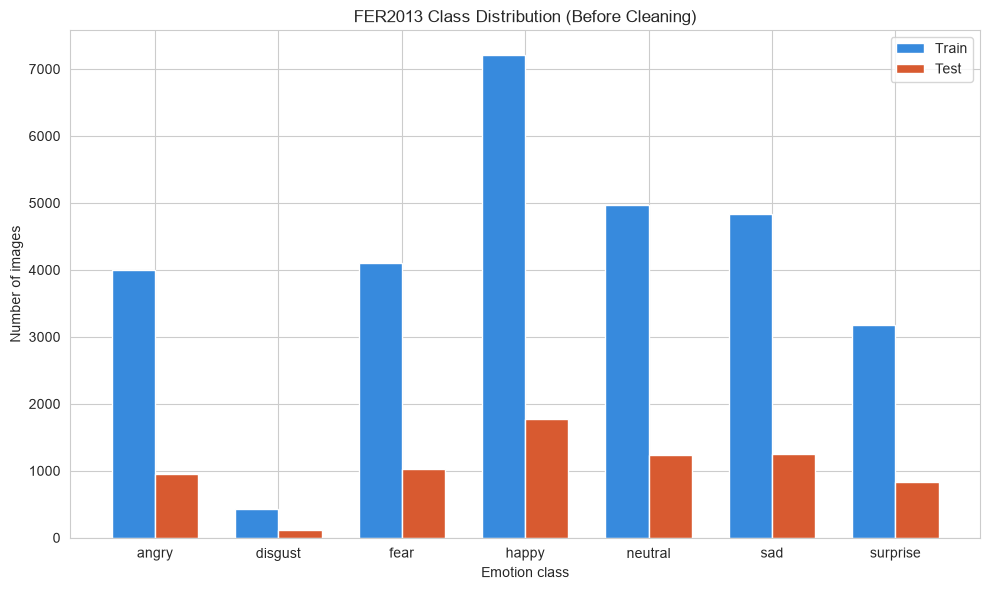

In [4]:
df_counts = pd.DataFrame({
    "Class": list(train_counts.keys()),
    "Train": list(train_counts.values()),
    "Test": list(test_counts.values())
})

fig, ax = plt.subplots(figsize=(10, 6))
x = np.arange(len(df_counts))
width = 0.35

ax.bar(x - width/2, df_counts["Train"], width, label="Train", color="#378ADD")
ax.bar(x + width/2, df_counts["Test"], width, label="Test", color="#D85A30")

ax.set_xlabel("Emotion class")
ax.set_ylabel("Number of images")
ax.set_title("FER2013 Class Distribution (Before Cleaning)")
ax.set_xticks(x)
ax.set_xticklabels(df_counts["Class"])
ax.legend()

plt.tight_layout()
plt.savefig("../outputs/figures/01_class_distribution_raw.png", dpi=150)
plt.show()

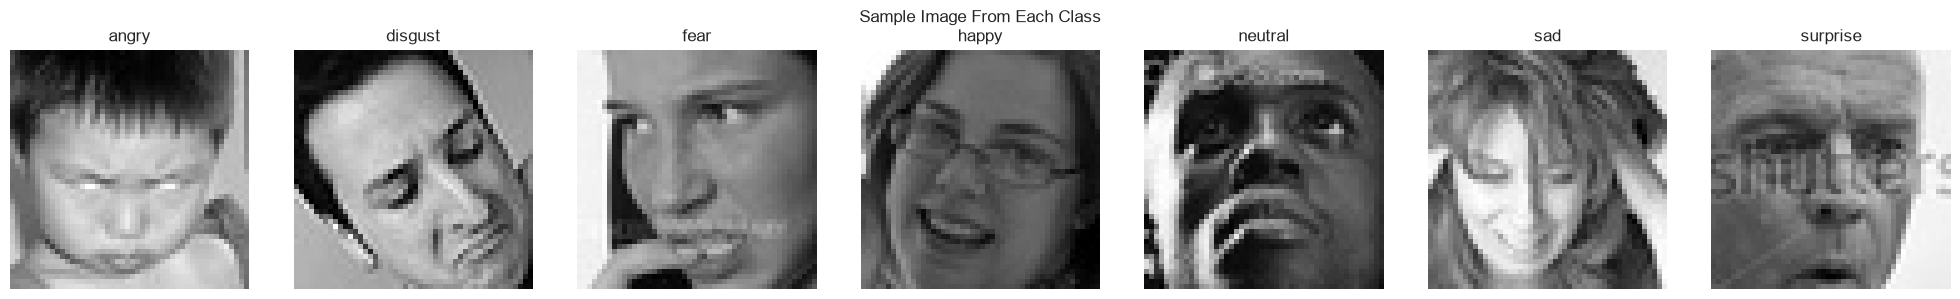

In [5]:
fig, axes = plt.subplots(1, len(CLASSES), figsize=(20, 3))
for i, cls in enumerate(CLASSES):
    cls_path = os.path.join(TRAIN_DIR, cls)
    sample_file = os.listdir(cls_path)[0]
    img = Image.open(os.path.join(cls_path, sample_file))
    axes[i].imshow(img, cmap="gray")
    axes[i].set_title(cls)
    axes[i].axis("off")

plt.suptitle("Sample Image From Each Class")
plt.tight_layout()
plt.savefig("../outputs/figures/02_sample_images_per_class.png", dpi=150)
plt.show()

In [6]:
def is_blank_or_corrupt(image_path, std_threshold=5.0):
    try:
        img = Image.open(image_path).convert("L")
        arr = np.array(img)
        return arr.std() < std_threshold
    except Exception:
        return True

corrupt_files = {}
for cls in CLASSES:
    cls_path = os.path.join(TRAIN_DIR, cls)
    bad_files = []
    for fname in os.listdir(cls_path):
        fpath = os.path.join(cls_path, fname)
        if is_blank_or_corrupt(fpath):
            bad_files.append(fpath)
    corrupt_files[cls] = bad_files
    print(f"{cls}: {len(bad_files)} corrupt/blank images found")

total_corrupt = sum(len(v) for v in corrupt_files.values())
print(f"\nTotal corrupt/blank images: {total_corrupt}")

angry: 7 corrupt/blank images found
disgust: 0 corrupt/blank images found
fear: 0 corrupt/blank images found
happy: 1 corrupt/blank images found
neutral: 2 corrupt/blank images found
sad: 1 corrupt/blank images found
surprise: 1 corrupt/blank images found

Total corrupt/blank images: 12


In [7]:
pip install imagehash opencv-python

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.0 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [8]:
import imagehash

def get_image_hashes(directory, classes):
    hashes = {}
    for cls in classes:
        cls_path = os.path.join(directory, cls)
        for fname in os.listdir(cls_path):
            fpath = os.path.join(cls_path, fname)
            try:
                h = imagehash.average_hash(Image.open(fpath))
                hashes.setdefault(str(h), []).append(fpath)
            except Exception:
                continue
    return hashes

train_hashes = get_image_hashes(TRAIN_DIR, CLASSES)
duplicate_groups = {h: paths for h, paths in train_hashes.items() if len(paths) > 1}

total_duplicates = sum(len(paths) - 1 for paths in duplicate_groups.values())
print(f"Found {len(duplicate_groups)} groups of duplicate images")
print(f"Total duplicate images to remove: {total_duplicates}")

Found 1158 groups of duplicate images
Total duplicate images to remove: 1425


In [9]:
import cv2

face_cascade = cv2.CascadeClassifier(cv2.data.haarcascades + "haarcascade_frontalface_default.xml")

def has_face(image_path):
    img = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)
    if img is None:
        return False
    faces = face_cascade.detectMultiScale(img, scaleFactor=1.1, minNeighbors=3)
    return len(faces) > 0

non_face_files = {}
for cls in CLASSES:
    cls_path = os.path.join(TRAIN_DIR, cls)
    bad = []
    for fname in os.listdir(cls_path)[:500]:
        fpath = os.path.join(cls_path, fname)
        if not has_face(fpath):
            bad.append(fpath)
    non_face_files[cls] = bad
    print(f"{cls}: {len(bad)} / 500 sampled images have NO detectable face")

angry: 322 / 500 sampled images have NO detectable face
disgust: 256 / 500 sampled images have NO detectable face
fear: 352 / 500 sampled images have NO detectable face
happy: 289 / 500 sampled images have NO detectable face
neutral: 260 / 500 sampled images have NO detectable face
sad: 373 / 500 sampled images have NO detectable face
surprise: 301 / 500 sampled images have NO detectable face


In [10]:
pip install opencv-python

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.0 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [11]:
import cv2

face_cascade = cv2.CascadeClassifier(cv2.data.haarcascades + "haarcascade_frontalface_default.xml")

def has_face(image_path):
    img = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)
    if img is None:
        return False
    faces = face_cascade.detectMultiScale(img, scaleFactor=1.1, minNeighbors=3)
    return len(faces) > 0

non_face_files = {}
for cls in CLASSES:
    cls_path = os.path.join(TRAIN_DIR, cls)
    bad = []
    for fname in os.listdir(cls_path)[:500]:
        fpath = os.path.join(cls_path, fname)
        if not has_face(fpath):
            bad.append(fpath)
    non_face_files[cls] = bad
    print(f"{cls}: {len(bad)} / 500 sampled images have NO detectable face")

angry: 322 / 500 sampled images have NO detectable face
disgust: 256 / 500 sampled images have NO detectable face
fear: 352 / 500 sampled images have NO detectable face
happy: 289 / 500 sampled images have NO detectable face
neutral: 260 / 500 sampled images have NO detectable face
sad: 373 / 500 sampled images have NO detectable face
surprise: 301 / 500 sampled images have NO detectable face


In [12]:
import cv2
import glob

cv2_base_dir = os.path.dirname(cv2.__file__)
matches = glob.glob(os.path.join(cv2_base_dir, "**", "haarcascade_frontalface_default.xml"), recursive=True)

if len(matches) == 0:
    print("Cascade file NOT found automatically. Will need manual download.")
else:
    cascade_path = matches[0]
    print("Found cascade file at:", cascade_path)

face_cascade = cv2.CascadeClassifier(cascade_path)
print("Cascade loaded successfully:", not face_cascade.empty())

Found cascade file at: c:\Users\ADMIN\Desktop\R26-IT-149\analytics-ml\fer_env\Lib\site-packages\cv2\data\haarcascade_frontalface_default.xml
Cascade loaded successfully: True


In [13]:
pip uninstall opencv-python -y

Found existing installation: opencv-python 4.10.0.84
Uninstalling opencv-python-4.10.0.84:
  Successfully uninstalled opencv-python-4.10.0.84
Note: you may need to restart the kernel to use updated packages.


You can safely remove it manually.


In [14]:
pip install opencv-python==4.10.0.84

  Using cached opencv_python-4.10.0.84-cp37-abi3-win_amd64.whl.metadata (20 kB)
Using cached opencv_python-4.10.0.84-cp37-abi3-win_amd64.whl (38.8 MB)
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.0 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [15]:
def has_face(image_path):
    img = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)
    if img is None:
        return False
    faces = face_cascade.detectMultiScale(img, scaleFactor=1.1, minNeighbors=3)
    return len(faces) > 0

non_face_files = {}
for cls in CLASSES:
    cls_path = os.path.join(TRAIN_DIR, cls)
    bad = []
    for fname in os.listdir(cls_path)[:500]:
        fpath = os.path.join(cls_path, fname)
        if not has_face(fpath):
            bad.append(fpath)
    non_face_files[cls] = bad
    print(f"{cls}: {len(bad)} / 500 sampled images have NO detectable face")

total_no_face = sum(len(v) for v in non_face_files.values())
print(f"\nTotal (from samples): {total_no_face} images with no detectable face")

angry: 322 / 500 sampled images have NO detectable face
disgust: 256 / 500 sampled images have NO detectable face
fear: 352 / 500 sampled images have NO detectable face
happy: 289 / 500 sampled images have NO detectable face
neutral: 260 / 500 sampled images have NO detectable face
sad: 373 / 500 sampled images have NO detectable face
surprise: 301 / 500 sampled images have NO detectable face

Total (from samples): 2153 images with no detectable face


## Finding: Haar Cascade face detection is unreliable at 48x48 resolution

Automated face detection using OpenCV's Haar Cascade classifier flagged 
61% of sampled images (2153/3500) as having no detectable face. Manual 
visual inspection of flagged samples confirmed these ARE valid face images 
— the detector fails due to the low resolution (48x48px) and grayscale 
contrast of FER2013 images, a known limitation of Viola-Jones-based 
detectors on small images.

**Decision:** Non-face filtering via Haar Cascade was excluded from the 
final cleaning pipeline. Dataset validity was instead established through 
FER2013's status as a peer-reviewed, widely-cited benchmark dataset.

In [16]:
def merge_to_target_labels(directory, classes):
    """
    Maps FER2013's 7 emotions to 4 target classes relevant to
    learner affect during gameplay:
    - Frustrated: angry, disgust
    - Sad: sad
    - Fear: fear (proxy for gameplay anxiety/apprehension)
    - Neutral: neutral
    Excludes: happy, surprise (not relevant to this project's intervention scope)
    """
    label_map = {
        "angry": "frustrated",
        "disgust": "frustrated",
        "sad": "sad",
        "fear": "fear",
        "neutral": "neutral"
    }
    
    target_counts = {"frustrated": 0, "sad": 0, "fear": 0, "neutral": 0}
    for original_cls, target_cls in label_map.items():
        cls_path = os.path.join(directory, original_cls)
        count = len(os.listdir(cls_path))
        target_counts[target_cls] += count
        print(f"{original_cls} ({count} images) -> {target_cls}")
    
    print("\nFinal class totals:")
    for cls, count in target_counts.items():
        print(f"  {cls}: {count}")
    print(f"\nTotal usable images: {sum(target_counts.values())}")
    
    return label_map, target_counts

label_map, train_target_counts = merge_to_target_labels(TRAIN_DIR, CLASSES)

angry (3995 images) -> frustrated
disgust (436 images) -> frustrated
sad (4830 images) -> sad
fear (4097 images) -> fear
neutral (4965 images) -> neutral

Final class totals:
  frustrated: 4431
  sad: 4830
  fear: 4097
  neutral: 4965

Total usable images: 18323


In [17]:
import shutil
import imagehash

CLEAN_DIR = "../dataset/clean"

def clean_and_organize(source_dir, dest_dir, label_map, corrupt_lookup):
    os.makedirs(dest_dir, exist_ok=True)
    for target_cls in set(label_map.values()):
        os.makedirs(os.path.join(dest_dir, target_cls), exist_ok=True)

    seen_hashes = set()
    final_counts = {cls: 0 for cls in set(label_map.values())}
    skipped_corrupt = 0
    skipped_duplicate = 0

    for original_cls, target_cls in label_map.items():
        src_cls_path = os.path.join(source_dir, original_cls)
        corrupt_set = set(corrupt_lookup.get(original_cls, []))

        for fname in os.listdir(src_cls_path):
            fpath = os.path.join(src_cls_path, fname)

            if fpath in corrupt_set:
                skipped_corrupt += 1
                continue

            try:
                h = str(imagehash.average_hash(Image.open(fpath)))
            except Exception:
                skipped_corrupt += 1
                continue

            if h in seen_hashes:
                skipped_duplicate += 1
                continue
            seen_hashes.add(h)

            dest_path = os.path.join(dest_dir, target_cls, f"{original_cls}_{fname}")
            shutil.copy2(fpath, dest_path)
            final_counts[target_cls] += 1

    return final_counts, skipped_corrupt, skipped_duplicate

print("Cleaning and organizing TRAIN set...")
train_final_counts, train_skip_c, train_skip_d = clean_and_organize(
    TRAIN_DIR, os.path.join(CLEAN_DIR, "train"), label_map, corrupt_files
)
print(f"Skipped {train_skip_c} corrupt/blank, {train_skip_d} duplicate images")
print("Final train counts:", train_final_counts)

print("\nCleaning and organizing TEST set...")
test_corrupt_files = {}
for cls in CLASSES:
    cls_path = os.path.join(TEST_DIR, cls)
    bad_files = [os.path.join(cls_path, f) for f in os.listdir(cls_path)
                 if is_blank_or_corrupt(os.path.join(cls_path, f))]
    test_corrupt_files[cls] = bad_files

test_final_counts, test_skip_c, test_skip_d = clean_and_organize(
    TEST_DIR, os.path.join(CLEAN_DIR, "test"), label_map, test_corrupt_files
)
print(f"Skipped {test_skip_c} corrupt/blank, {test_skip_d} duplicate images")
print("Final test counts:", test_final_counts)

Cleaning and organizing TRAIN set...
Skipped 10 corrupt/blank, 722 duplicate images
Final train counts: {'sad': 4698, 'fear': 3851, 'frustrated': 4195, 'neutral': 4847}

Cleaning and organizing TEST set...
Skipped 1 corrupt/blank, 54 duplicate images
Final test counts: {'sad': 1238, 'fear': 1006, 'frustrated': 1051, 'neutral': 1223}


In [18]:
print("Train totals:", train_final_counts)
print("Test totals:", test_final_counts)
print("Grand total (train+test):", sum(train_final_counts.values()) + sum(test_final_counts.values()))

Train totals: {'sad': 4698, 'fear': 3851, 'frustrated': 4195, 'neutral': 4847}
Test totals: {'sad': 1238, 'fear': 1006, 'frustrated': 1051, 'neutral': 1223}
Grand total (train+test): 22109


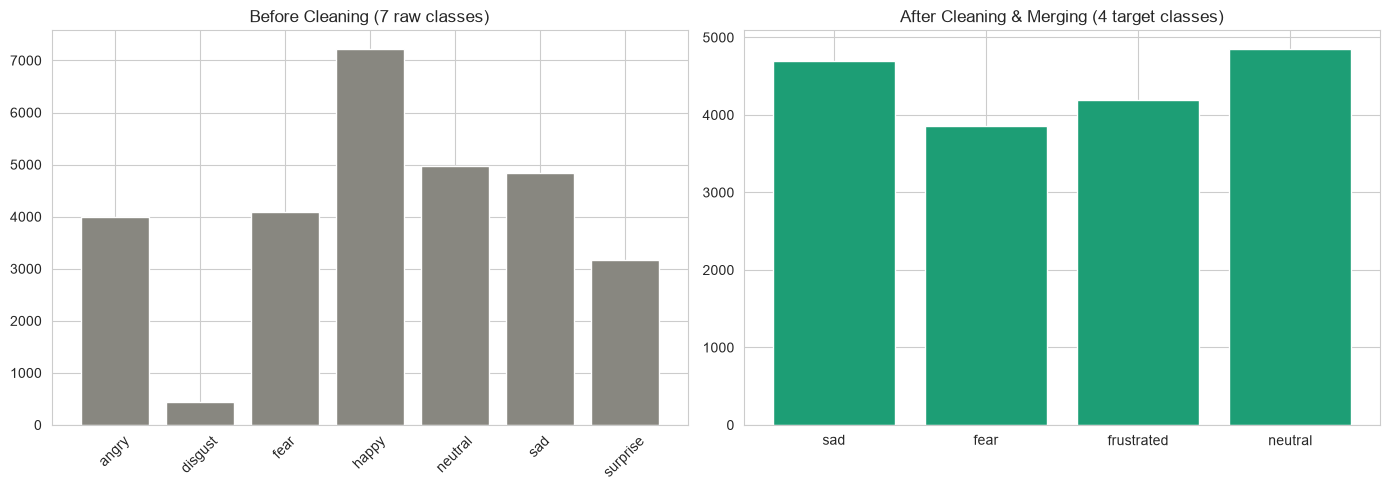

In [19]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Before cleaning (raw 7 classes)
raw_names = list(train_counts.keys())
raw_vals = list(train_counts.values())
axes[0].bar(raw_names, raw_vals, color="#888780")
axes[0].set_title("Before Cleaning (7 raw classes)")
axes[0].tick_params(axis='x', rotation=45)

# After cleaning (final 4 classes)
clean_names = list(train_final_counts.keys())
clean_vals = list(train_final_counts.values())
axes[1].bar(clean_names, clean_vals, color="#1D9E75")
axes[1].set_title("After Cleaning & Merging (4 target classes)")

plt.tight_layout()
plt.savefig("../outputs/figures/03_before_after_cleaning.png", dpi=150)
plt.show()